## Figure 5

The input files are available at [our repository on Zenodo](https://doi.org/10.5281/zenodo.19499423).

In [1]:
import os
import numpy as np
import pandas as pd

import scanpy as sc

from matplotlib import pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportion_confint

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

### Figure 5d - region annotation

In [2]:
adata = sc.read_h5ad('visiumhd_data_analysis/V1_cell.h5ad')

/scratch/lim4020_15099435/ipykernel_3522597/2450054980.py:5: UserWarning: The palette list has more values (11) than needed (9), which may not be intended.
  scatter = sns.scatterplot(data=adata.obs, x='x', y='y',


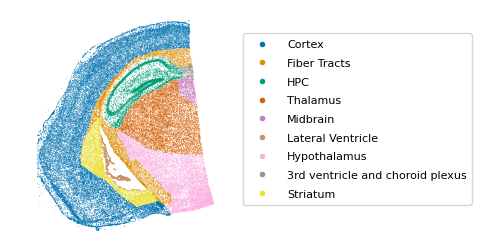

In [3]:
fig, ax = plt.subplots(figsize=(3,3))

palette = sns.color_palette("colorblind", 10) + ['lightgrey']

scatter = sns.scatterplot(data=adata.obs, x='x', y='y',
                          hue='region', s=0.2, 
                          edgecolor='none', ax=ax,
                          rasterized=True,
                          hue_order=['Cortex', 'Fiber Tracts',
                                     'HPC', 'Thalamus', 'Midbrain',
                                     'Lateral Ventricle','Hypothalamus',
                                     '3rd ventricle and choroid plexus', 
                                     'Striatum'],
                          palette=palette)

# Remove ticks, labels, and axes spines
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
sns.despine(ax=ax, top=True, right=True, left=True, bottom=True)

# Set equal aspect ratio
ax.set_aspect('equal', adjustable='datalim')

# Customize legend
legend = ax.legend(
    title='',
    bbox_to_anchor=(1., 0.9),   # Move it outside the right
    loc='upper left',           # Align top-left of legend box to that point
    borderaxespad=0.
)
for text in legend.get_texts():
    text.set_fontsize(8)

ax.invert_yaxis()

# Increase legend marker size
for handle in legend.legend_handles:
    handle.set_markersize(4)  # Adjust size; default is ~4–5

plt.show()


### Figure 5e - No. of SVI

In [4]:
dir_v1_ont = 'visiumhd_data_analysis/V1_ONT/isomatrix/res/MoransI_'
dir_v1_pb= 'visiumhd_data_analysis/V1_PB/isomatrix/res/MoransI_'
dir_V2 = 'visiumhd_data_analysis/V2_ONT/isomatrix/res/MoransI_'
dir_V3 = 'visiumhd_data_analysis/V3_PB/isomatrix/res/MoransI_'

fn_end = '_nperm100000_k50_mincells250_mincellspergroup20_imb0.05_seed0.csv'

m_v1_ont = pd.read_csv(f'{dir_v1_ont}scores{fn_end}',
                   index_col=0)
p_v1_ont = pd.read_csv(f'{dir_v1_ont}pval{fn_end}',
                   index_col=0)
q_v1_ont = pd.read_csv(f'{dir_v1_ont}qval{fn_end}',
                   index_col=0)

m_v1_pb = pd.read_csv(f'{dir_v1_pb}scores{fn_end}',
                   index_col=0)
p_v1_pb = pd.read_csv(f'{dir_v1_pb}pval{fn_end}',
                   index_col=0)
q_v1_pb = pd.read_csv(f'{dir_v1_pb}qval{fn_end}',
                   index_col=0)

m_V2 = pd.read_csv(f'{dir_V2}scores{fn_end}',
                   index_col=0)
p_V2 = pd.read_csv(f'{dir_V2}pval{fn_end}',
                   index_col=0)
q_V2 = pd.read_csv(f'{dir_V2}qval{fn_end}',
                   index_col=0)

m_V3 = pd.read_csv(f'{dir_V3}scores{fn_end}',
                   index_col=0)
p_V3 = pd.read_csv(f'{dir_V3}pval{fn_end}',
                   index_col=0)
q_V3 = pd.read_csv(f'{dir_V3}qval{fn_end}',
                   index_col=0)

In [5]:
# Manually inflate adj p-value for isoforms with a low moran's I score
q_v1_ont[m_v1_ont < 0.01] = 1
q_v1_pb[m_v1_pb < 0.01] = 1
q_V2[m_V2 < 0.01] = 1
q_V3[m_V3 < 0.01] = 1


In [6]:
# Combine data per cell type
q_all = pd.concat((q_v1_ont['All'], q_v1_pb['All'], q_V2['All'], q_V3['All']),axis=1)
q_all.columns = ['V1 (ONT)', 'V1 (PB)', 'V2 (ONT)', 'V3 (PB)']

q_exc = pd.concat((q_v1_ont['ExciteNeuron'], q_v1_pb['ExciteNeuron'], q_V2['ExciteNeuron'], q_V3['ExciteNeuron']),axis=1)
q_exc.columns = ['V1 (ONT)', 'V1 (PB)', 'V2 (ONT)', 'V3 (PB)']

q_inh = pd.concat((q_v1_ont['InhibNeuron'], q_v1_pb['InhibNeuron'], q_V2['InhibNeuron'], q_V3['InhibNeuron']),axis=1)
q_inh.columns = ['V1 (ONT)', 'V1 (PB)', 'V2 (ONT)', 'V3 (PB)']

q_ast = pd.concat((q_v1_ont['Astro'], q_v1_pb['Astro'], q_V2['Astro'], q_V3['Astro']),axis=1)
q_ast.columns = ['V1 (ONT)', 'V1 (PB)', 'V2 (ONT)', 'V3 (PB)']

q_oli = pd.concat((q_v1_ont['Oligo'], q_v1_pb['Oligo'], q_V2['Oligo'], q_V3['Oligo']),axis=1)
q_oli.columns = ['V1 (ONT)', 'V1 (PB)', 'V2 (ONT)', 'V3 (PB)']


In [7]:
# Remove isoforms never tested
q_all = q_all[q_all.isna().all(axis=1) == False]
q_exc = q_exc[q_exc.isna().all(axis=1) == False]
q_inh = q_inh[q_inh.isna().all(axis=1) == False]
q_oli = q_oli[q_oli.isna().all(axis=1) == False]
q_ast = q_ast[q_ast.isna().all(axis=1) == False]



In [8]:
### Subset novel isoforms
q_all_novel = q_all.iloc[np.where(pd.DataFrame(q_all.index)['Transcript ID'].str.split('.', expand=True, n=3)[2].notna())[0]]
q_exc_novel = q_exc.iloc[np.where(pd.DataFrame(q_exc.index)['Transcript ID'].str.split('.', expand=True, n=3)[2].notna())[0]]
q_inh_novel = q_inh.iloc[np.where(pd.DataFrame(q_inh.index)['Transcript ID'].str.split('.', expand=True, n=3)[2].notna())[0]]
q_oli_novel = q_oli.iloc[np.where(pd.DataFrame(q_oli.index)['Transcript ID'].str.split('.', expand=True, n=3)[2].notna())[0]]
q_ast_novel = q_ast.iloc[np.where(pd.DataFrame(q_ast.index)['Transcript ID'].str.split('.', expand=True, n=3)[2].notna())[0]]


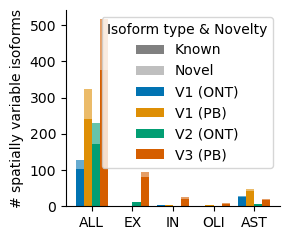

In [9]:
## Significant isoforms per dataset per celltype
sign_all = (q_all < 0.05).sum().reset_index()
sign_all['celltype'] = 'All'

sign_exc = (q_exc < 0.05).sum().reset_index()
sign_exc['celltype'] = 'Excite'

sign_inh = (q_inh < 0.05).sum().reset_index()
sign_inh['celltype'] = 'Inhib'

sign_oli = (q_oli < 0.05).sum().reset_index()
sign_oli['celltype'] = 'Oligo'

sign_ast = (q_ast < 0.05).sum().reset_index()
sign_ast['celltype'] = 'Astro'

sign_ct = pd.concat((sign_all, sign_exc, sign_inh, sign_oli, sign_ast),axis=0)

# Significant novel isoforms per dataset per celltype
sign_all_novel = (q_all_novel < 0.05).sum().reset_index()
sign_all_novel['celltype'] = 'All'

sign_exc_novel = (q_exc_novel < 0.05).sum().reset_index()
sign_exc_novel['celltype'] = 'Excite'

sign_inh_novel = (q_inh_novel < 0.05).sum().reset_index()
sign_inh_novel['celltype'] = 'Inhib'

sign_oli_novel = (q_oli_novel < 0.05).sum().reset_index()
sign_oli_novel['celltype'] = 'Oligo'

sign_ast_novel = (q_ast_novel < 0.05).sum().reset_index()
sign_ast_novel['celltype'] = 'Astro'

sign_ct_novel = pd.concat((sign_all_novel, sign_exc_novel, sign_inh_novel, sign_oli_novel, sign_ast_novel),axis=0)

# Merge the two
sign_ct_merged = sign_ct.merge(sign_ct_novel, on=['index', 'celltype'], suffixes=('_total', '_novel'))

celltypes = sign_ct_merged['celltype'].unique()
indices = sign_ct_merged['index'].unique()
x = np.arange(len(celltypes))
width = 0.2

palette = sns.color_palette('colorblind', n_colors=len(indices))
index_to_color = dict(zip(indices, palette))

legend_patches = []
from matplotlib.patches import Patch

plt.figure(figsize=(3,2.5))

for i, exon_type in enumerate(indices):
    sub_df = sign_ct_merged[sign_ct_merged['index'] == exon_type].set_index('celltype').loc[celltypes].reset_index()

    # Known (bottom)
    known_vals = sub_df['0_total'] - sub_df['0_novel']
    p1 = plt.bar(x + i*width, known_vals, width, 
                 color=index_to_color[exon_type], label=exon_type)

    # Novel (top, slightly transparent or hatched)
    p2 = plt.bar(x + i*width, sub_df['0_novel'], width, 
                 bottom=known_vals, 
                 color=index_to_color[exon_type], alpha=0.6)

# Axis labels
plt.xticks(x + width * (len(indices)-1)/2, ['ALL', 'EX', 'IN', 'OLI', 'AST'])
plt.ylabel('# spatially variable isoforms')
plt.xlabel('')
plt.tight_layout()

# Custom legend
legend_elements = [
    Patch(facecolor='gray', label='Known'),
    Patch(facecolor='gray', alpha=0.5, label='Novel')
] + [
    Patch(facecolor=index_to_color[ind], label=ind) for ind in indices
]

plt.legend(handles=legend_elements, title='Isoform type & Novelty')
sns.despine()
plt.show()

### Figure 5c - percentage of SVI

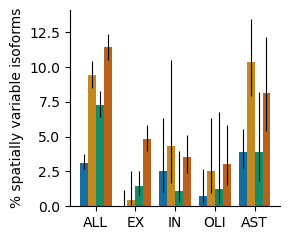

In [10]:
ci_low, ci_upp = proportion_confint((q_all < 0.05).sum(), (q_all.notna().sum()), method='wilson')

perc_sign_all = (100*(q_all < 0.05).sum()/q_all.notna().sum()).reset_index()
perc_sign_all['celltype'] = 'All'
ci_low, ci_upp = proportion_confint((q_all < 0.05).sum(), (q_all.notna().sum()), method='wilson')
perc_sign_all['ci_low'] = ci_low.values*100
perc_sign_all['ci_upp'] = ci_upp.values*100

perc_sign_exc = (100*(q_exc < 0.05).sum()/q_exc.notna().sum()).reset_index()
perc_sign_exc['celltype'] = 'Excite'
ci_low, ci_upp = proportion_confint((q_exc < 0.05).sum(), (q_exc.notna().sum()), method='wilson')
perc_sign_exc['ci_low'] = ci_low.values*100
perc_sign_exc['ci_upp'] = ci_upp.values*100

perc_sign_inh = (100*(q_inh < 0.05).sum()/q_inh.notna().sum()).reset_index()
perc_sign_inh['celltype'] = 'Inhib'
ci_low, ci_upp = proportion_confint((q_inh < 0.05).sum(), (q_inh.notna().sum()), method='wilson')
perc_sign_inh['ci_low'] = ci_low.values*100
perc_sign_inh['ci_upp'] = ci_upp.values*100

perc_sign_ast = (100*(q_ast < 0.05).sum()/q_ast.notna().sum()).reset_index()
perc_sign_ast['celltype'] = 'Astro'
ci_low, ci_upp = proportion_confint((q_ast < 0.05).sum(), (q_ast.notna().sum()), method='wilson')
perc_sign_ast['ci_low'] = ci_low.values*100
perc_sign_ast['ci_upp'] = ci_upp.values*100

perc_sign_oli = (100*(q_oli < 0.05).sum()/q_oli.notna().sum()).reset_index()
perc_sign_oli['celltype'] = 'Oligo'
ci_low, ci_upp = proportion_confint((q_oli < 0.05).sum(), (q_oli.notna().sum()), method='wilson')
perc_sign_oli['ci_low'] = ci_low.values*100
perc_sign_oli['ci_upp'] = ci_upp.values*100

perc_sign_ct = pd.concat((perc_sign_all, perc_sign_exc, perc_sign_inh, perc_sign_oli, perc_sign_ast),axis=0)

lower_err = perc_sign_ct[0] - perc_sign_ct['ci_low']
upper_err = perc_sign_ct['ci_upp'] - perc_sign_ct[0]
yerr = np.array([lower_err.values, upper_err.values])

plt.figure(figsize=(3,2.5))
ax = sns.barplot(data=perc_sign_ct, x='celltype', y=0, hue='index',
                 palette=palette)

x_loc = []

for i, bar in enumerate(ax.patches):
    x_loc.append(bar.get_x() + bar.get_width() / 2)

x_loc = np.array(x_loc)[:20]
plt.errorbar(x=np.sort(x_loc),
            y=perc_sign_ct[0],
            yerr=yerr,
            fmt='none',
            capsize=0,
            ecolor='black',
            elinewidth=0.8)
    
sns.despine()
plt.ylabel('% spatially variable isoforms')
plt.xlabel('')
plt.xticks(ax.get_xticks(), labels=['ALL','EX','IN', 'OLI', 'AST'])
plt.tight_layout()
plt.legend('',frameon=False)
plt.show()

### Figure 5g - overlap PacBio and ONT

In [11]:
from matplotlib_venn import venn2

genes_tested_V1_ONT = q_all.index[q_all['V1 (ONT)'].notna()]
genes_tested_V1_PB = q_all.index[q_all['V1 (PB)'].notna()]
genes_tested_V1_both = np.intersect1d(genes_tested_V1_ONT,
                                      genes_tested_V1_PB)
genes_tested_V1_ONT_only = np.setdiff1d(genes_tested_V1_ONT,
                                        genes_tested_V1_PB)
genes_tested_V1_PB_only = np.setdiff1d(genes_tested_V1_PB,
                                        genes_tested_V1_ONT)



In [12]:
genes_sig_V1_ONT = q_all.loc[genes_tested_V1_both].index[q_all.loc[genes_tested_V1_both, 'V1 (ONT)'] < 0.05]
genes_sig_V1_PB = q_all.loc[genes_tested_V1_both].index[q_all.loc[genes_tested_V1_both, 'V1 (PB)'] < 0.05]
genes_sig_V1_both = np.intersect1d(genes_sig_V1_ONT,
                                   genes_sig_V1_PB)
genes_sig_V1_ONT_only = np.setdiff1d(genes_sig_V1_ONT,
                                     genes_sig_V1_PB)
genes_sig_V1_PB_only = np.setdiff1d(genes_sig_V1_PB,
                                    genes_sig_V1_ONT)



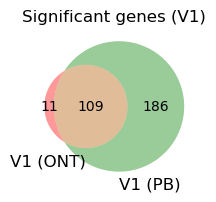

In [13]:
plt.figure(figsize=(3,2))
venn2(subsets=(len(genes_sig_V1_ONT_only), 
               len(genes_sig_V1_PB_only), 
               len(genes_sig_V1_both)), 
      set_labels=("V1 (ONT)", "V1 (PB)"))
plt.title(f"Significant genes (V1)")
plt.show()




### Figure 5h - overlap Stereo-seq and Visium HD

In [14]:
q_S1S2 = pd.read_csv('stereoseq_data_analysis/comb_AE_ONT/isomatrix/res_comb/MoransI_qval_nperm100000_k50_mincells250_mincellspergroup20_imb0.05_seed0.csv',
                     index_col=0)

m_S1S2 = pd.read_csv('stereoseq_data_analysis/comb_AE_ONT/isomatrix/res_comb/MoransI_scores_nperm100000_k50_mincells250_mincellspergroup20_imb0.05_seed0.csv',
                     index_col=0)

q_S1S2.head()

,All,ExciteNeuron,InhibNeuron,Astro,Oligo
Transcript ID,,,,,
ENSMUST00000038080.7,NaN,NaN,NaN,NaN,NaN
ENSMUST00000232945.2,NaN,NaN,NaN,NaN,NaN
ENSMUST00000009344.16,NaN,NaN,NaN,NaN,NaN
ENSMUST00000168189.8,NaN,NaN,NaN,NaN,NaN
ENSMUST00000034567.4,1.0,1.0,NaN,NaN,NaN


In [15]:
q_S1S2[m_S1S2 < 0.01] = 1

In [16]:
genes_tested_S1S2_ONT = q_S1S2.index[q_S1S2['All'].notna()]
genes_tested_V1_PB = q_all.index[q_all['V1 (PB)'].notna()]
genes_tested_SV_both = np.intersect1d(genes_tested_S1S2_ONT,
                                      genes_tested_V1_PB)
genes_tested_S1S2_ONT_only = np.setdiff1d(genes_tested_S1S2_ONT,
                                        genes_tested_V1_PB)
genes_tested_V1_PB_only = np.setdiff1d(genes_tested_V1_PB,
                                        genes_tested_S1S2_ONT)



In [17]:
genes_sig_S12_ONT = q_S1S2.loc[genes_tested_SV_both].index[q_S1S2.loc[genes_tested_SV_both, 'All'] < 0.05]
genes_sig_V1_PB = q_all.loc[genes_tested_SV_both].index[q_all.loc[genes_tested_SV_both, 'V1 (PB)'] < 0.05]
genes_sig_SV_both = np.intersect1d(genes_sig_S12_ONT,
                                   genes_sig_V1_PB)
genes_sig_S12_ONT_only = np.setdiff1d(genes_sig_S12_ONT,
                                     genes_sig_V1_PB)
genes_sig_V1_PB_only = np.setdiff1d(genes_sig_V1_PB,
                                    genes_sig_S12_ONT)


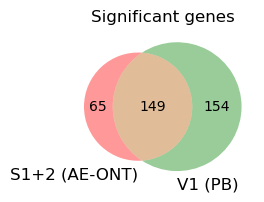

In [18]:
plt.figure(figsize=(3,2))
venn2(subsets=(len(genes_sig_S12_ONT_only), 
               len(genes_sig_V1_PB_only), 
               len(genes_sig_SV_both)), 
      set_labels=("S1+2 (AE-ONT)", "V1 (PB)"))
plt.title(f"Significant genes")
plt.show()



### Figure 5i - expected vs. observed overlap

In [19]:
from scipy.stats import fisher_exact

a = len(genes_sig_SV_both)
b = len(genes_sig_S12_ONT_only)
c = len(genes_sig_V1_PB_only)
d = len(genes_tested_SV_both)-a-b-c

fisher_exact([[a,b],[c,d]])

SignificanceResult(statistic=37.7933066933067, pvalue=1.842376565710617e-110)

In [20]:
expected = (((a+b)/len(genes_tested_SV_both))*((a+c)/len(genes_tested_SV_both)))*len(genes_tested_SV_both)
expected

22.30546955624355

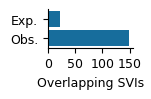

In [21]:
xx = pd.DataFrame([expected, len(genes_sig_SV_both)],
            index=['Exp.', 'Obs.']).reset_index()
xx['color'] = '1'

plt.figure(figsize=(1.1,0.5))
sns.barplot(data=xx,
            y='index',
            x=0, 
            hue='color',
            palette='colorblind',
           )
plt.legend('', frameon=False)
plt.ylabel('')
plt.xlabel('Overlapping SVIs', fontsize=9)
plt.xticks([0,50,100,150], fontsize=9)
plt.yticks(fontsize=9)
sns.despine()
plt.show()

### Figure 5j - Gad2 example

In [22]:
import SplIsoFind
from PIL import Image
Image.MAX_IMAGE_PIXELS = 553190400


/athena/tilgnerlab/scratch/lim4020/2022_08_15_PSIprediction/envs/SplIsoFind_016/lib/python3.9/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [23]:
im_reg_V1 = (Image.open('tissue_staining/V1_Center_1_01_20x_BF_01.tif')
             .rotate(90, expand=True)
             .transpose(Image.FLIP_TOP_BOTTOM))

imarray_V1 = np.array(im_reg_V1).mean(axis=2)


In [24]:
x_sparse, labels, isoforms = SplIsoFind.pp.load_sparse('visiumhd_data_analysis/V1_PB/isomatrix')


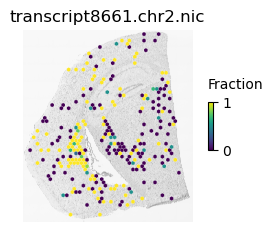

In [25]:
ax = SplIsoFind.pl.spatial_hexplot_sparse(x_sparse, 
                                          labels, 
                                          isoforms,
                                          'transcript8661.chr2.nic', 
                                          imarray=imarray_V1,
                                          celltype='', 
                                          hexsize=750, 
                                          fig_size= (4, 2.5), 
                                          staining_max='white',
                                          staining_min='grey')
ax.invert_yaxis() 
plt.show()
